# Sudoku con realidad aumentada

Programa que detecta el tablero de un sudoku en una imagen en vivo, reconoce
los dígitos ya escritos, resuelve el sudoku y dibuja la solución (sólo en las
casillas vacías) sobre la imagen original, respetando la perspectiva.

## Cómo funciona

1. **Detectar el tablero**: se prueban varios umbrales adaptativos y se busca el contorno exterior más parecido a un cuadrado. Si `approxPolyDP` da más de 4 vértices (pasa cuando el contorno se fusiona con el borde de la foto), se busca el subconjunto de 4 que forma el cuadrilátero más cuadrado. De todos los candidatos se elige el que más líneas de rejilla tiene al rectificarlo.

2. **Rectificar**: homografía de las 4 esquinas a un cuadrado 450×450 px.

3. **Leer los dígitos**: binarización adaptativa → 81 celdas de 50×50 → componente conexa mayor de cada celda → normalizar a 28×28 → clasificar con `digits.keras` (igual que `digitslive-4.py`).

4. **Resolver**: backtracking eligiendo siempre la casilla con menos candidatos. Si tarda demasiado (tablero mal leído), se aborta.

5. **Dibujar**: lienzo 450×450 con los dígitos en verde solo en las casillas vacías, proyectado con `H⁻¹` sobre la imagen original.

## Comprobación con imágenes estáticas

Probamos el proceso completo con `images/sudoku3.png` (sin necesidad de
cámara en directo).

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

import reader
from solver import solve

def fig(w,h):
    plt.figure(figsize=(w,h))

def readrgb(file):
    return cv.cvtColor(cv.imread(file), cv.COLOR_BGR2RGB)

N, CELL = reader.N, reader.CELL

img = cv.imread('../../images/sudoku3.png')
corners = reader.find_grid(img)
Hm = reader.grid_homography(corners)
warp = cv.warpPerspective(img, Hm, (N,N))
board = reader.read_board(warp)
print("tablero detectado:")
print(board)

tablero detectado:
[[5 3 0 0 7 0 0 0 0]
 [6 0 0 1 9 5 0 0 0]
 [0 9 8 0 0 0 0 5 0]
 [8 0 0 0 6 0 0 0 3]
 [4 0 0 8 0 3 0 0 1]
 [7 0 0 0 2 0 0 0 6]
 [0 6 0 0 0 0 2 8 0]
 [0 0 0 4 1 9 0 0 5]
 [0 0 0 0 8 0 0 7 9]]


In [2]:
sol = solve(board)
print("solución:")
print(sol)

solución:
[[5 3 4 6 7 8 9 1 2]
 [6 7 2 1 9 5 4 3 8]
 [1 9 8 3 4 2 6 5 7]
 [8 1 9 7 6 4 5 2 3]
 [4 2 6 8 5 3 7 9 1]
 [7 5 3 9 2 1 8 4 6]
 [9 6 1 5 3 7 2 8 4]
 [2 8 7 4 1 9 3 6 5]
 [3 4 5 2 8 6 1 7 9]]


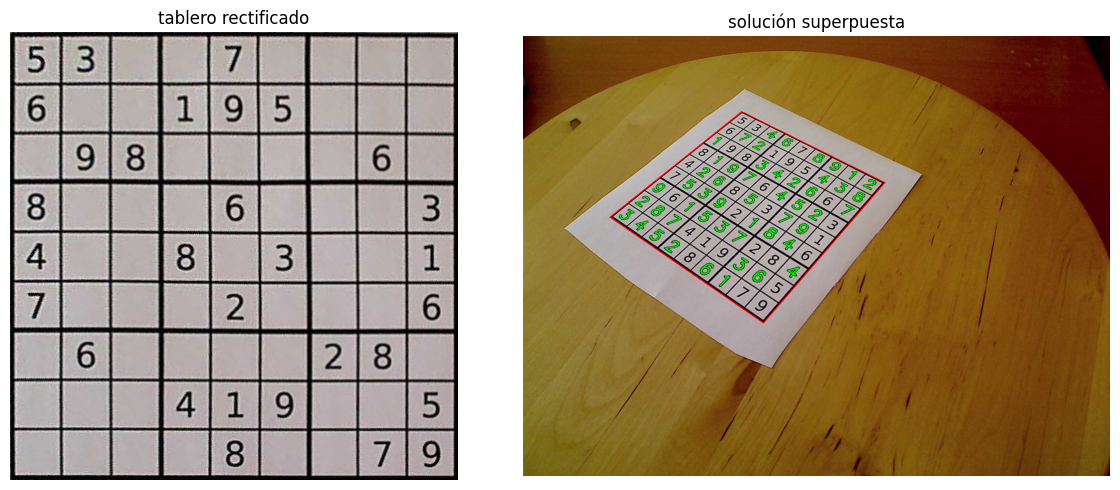

In [3]:
# lienzo con la solución (solo casillas vacías) y proyección sobre la imagen original
canvas = np.zeros((N,N,3), np.uint8)
for r in range(9):
    for c in range(9):
        if board[r,c] == 0:
            x = c*CELL + CELL//4
            y = r*CELL + 3*CELL//4
            cv.putText(canvas, str(sol[r,c]), (x,y), cv.FONT_HERSHEY_SIMPLEX, CELL/40, (0,255,0), 2, cv.LINE_AA)

invH = np.linalg.inv(Hm)
overlay = cv.warpPerspective(canvas, invH, (img.shape[1], img.shape[0]))
mask = overlay.any(axis=2)
out = img.copy()
out[mask] = overlay[mask]
cv.polylines(out, [corners.astype(int)], True, (0,0,255), 2)

fig(12,5)
plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(warp, cv.COLOR_BGR2RGB))
plt.title('tablero rectificado')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(out, cv.COLOR_BGR2RGB))
plt.title('solución superpuesta')
plt.axis('off')
plt.tight_layout()
plt.show()

La solución se dibuja en verde sólo en las casillas que estaban vacías,
respetando la perspectiva original de la foto.

### Limitaciones

- El reconocimiento de dígitos depende de la calidad/resolución de la
  imagen: con `images/sudoku2.png` (más borrosa) la red confunde algunos
  dígitos (p.ej. algún `6` con `5`, o `4`/`1` con `7`/`2`), lo que produce un
  tablero sin solución válida — en ese caso `solve` devuelve `None` y no se
  dibuja nada (se sigue intentando en cada fotograma).
- Si la hoja está muy curvada o en un ángulo muy cerrado
  (`images/sudoku.png`), la rejilla de 50x50 px no coincide con las celdas
  reales y la lectura falla por completo.

## `sudoku.py`: en directo

```
./sudoku.py --dev=0
```

El contorno del tablero se dibuja en rojo. Cuando el tablero se mantiene estable varios frames, se resuelve y la solución aparece en verde en perspectiva. Si no hay solución válida (dígito mal leído) se sigue intentando.

`g` para ver el tablero rectificado y su binarización. `t` para ver el umbral de detección.

## Ejemplo en directo

Resultado real de `./sudoku.py --dev=0`: el tablero detectado (contorno rojo)
con la solución superpuesta en verde sobre las casillas vacías, respetando la
perspectiva.

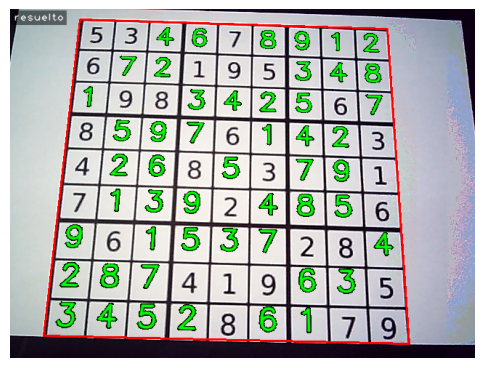

In [4]:
fig(6,5)
plt.imshow(readrgb('ejemplos/20260613-202620.png'))
plt.axis('off')
plt.show()